# Task 4: Context-Aware Chatbot Using RAG
## DevelopersHub Corporation – AI/ML Engineering Advanced Internship

### Problem Statement & Objective
Build a **conversational chatbot** that:
- Remembers multi-turn conversation history (context memory)
- Retrieves relevant answers from a **vectorized document store** (RAG)
- Uses **FAISS** for vector search and **Groq** (LLaMA-3) as the LLM
- Is deployed interactively via **Streamlit**

### Architecture
```
User Query
    ↓
SentenceTransformer Embedding (all-MiniLM-L6-v2)
    ↓
FAISS Index → Top-K Relevant Chunks
    ↓
Groq API (LLaMA-3 8B) + Chat History
    ↓
Response + Source Attribution
```

## 1. Install Dependencies

In [1]:
!pip install -q faiss-cpu sentence-transformers wikipedia groq

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.7/139.7 kB 10.3 MB/s eta 0:00:00


## 2. Dataset Loading & Preprocessing
### Fetching Wikipedia Articles as the Knowledge Corpus

In [2]:
import warnings
warnings.filterwarnings('ignore')

import wikipedia
import numpy as np
from sentence_transformers import SentenceTransformer
import faiss

print('Libraries imported successfully.')

Libraries imported successfully.


In [3]:
# ──────────────────────────────────────────────────────────────
# Fetch Wikipedia articles to build the knowledge corpus
# ──────────────────────────────────────────────────────────────
TOPICS = [
    'Artificial intelligence',
    'Machine learning',
    'Deep learning',
    'Natural language processing',
    'Transformer (machine learning model)',
    'Retrieval-augmented generation',
    'Large language model',
    'Python (programming language)',
]

corpus   = []   # raw text chunks
metadata = []   # corresponding article info

CHUNK_SIZE    = 500
CHUNK_OVERLAP = 50
STEP          = CHUNK_SIZE - CHUNK_OVERLAP

for topic in TOPICS:
    try:
        page = wikipedia.page(topic, auto_suggest=False)
        text = page.content[:6000]           # first 6 000 chars per article
        for i in range(0, len(text), STEP):
            chunk = text[i : i + CHUNK_SIZE]
            if len(chunk) > 80:              # skip tiny tail chunks
                corpus.append(chunk)
                metadata.append({'title': page.title, 'url': page.url})
        print(f'  Loaded: {page.title}')
    except Exception as e:
        print(f'  Skipped {topic}: {e}')

print(f'\nTotal articles  : {len(TOPICS)}')
print(f'Total chunks    : {len(corpus)}')
print(f'Avg chunk length: {int(np.mean([len(c) for c in corpus]))} chars')

  Loaded: Artificial intelligence
  Loaded: Machine learning
  Loaded: Deep learning
  Loaded: Natural language processing
  Loaded: Transformer (deep learning)
  Loaded: Retrieval-augmented generation
  Loaded: Large language model
  Loaded: Python (programming language)

Total articles  : 8
Total chunks    : 112
Avg chunk length: 475 chars


In [4]:
# Inspect a sample chunk
print('Sample chunk:\n' + '='*60)
print(corpus[10])
print(f'\nMetadata: {metadata[10]}')

Sample chunk:
e. Knowledge bases need to represent things such as objects, properties, categories, and relations between objects; situations, events, states, and time; causes and effects; knowledge about knowledge (what we know about what other people know); default reasoning (things that humans assume are true until they are told differently and will remain true even when other facts are changing); and many other aspects and domains of knowledge.
Among the most difficult problems in knowledge representation 

Metadata: {'title': 'Artificial intelligence', 'url': 'https://en.wikipedia.org/wiki/Artificial_intelligence'}


## 3. Building the Vector Store
### Embedding with SentenceTransformers + FAISS Index

In [5]:
# ──────────────────────────────────────────────────────────────
# Load embedding model
# all-MiniLM-L6-v2: 384-dim, fast, strong quality
# ──────────────────────────────────────────────────────────────
EMBED_MODEL = 'all-MiniLM-L6-v2'
print(f'Loading embedding model: {EMBED_MODEL} ...')
embed_model = SentenceTransformer(EMBED_MODEL)
print('Model loaded.')

# Encode every chunk
print('Encoding corpus ...')
embeddings = embed_model.encode(
    corpus,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
).astype('float32')

print(f'Embedding matrix shape: {embeddings.shape}')

Loading embedding model: all-MiniLM-L6-v2 ...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded.
Encoding corpus ...


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Embedding matrix shape: (112, 384)


In [6]:
# ──────────────────────────────────────────────────────────────
# Build FAISS index with cosine similarity
# ──────────────────────────────────────────────────────────────
dim = embeddings.shape[1]     # 384

# Normalise vectors so inner product == cosine similarity
faiss.normalize_L2(embeddings)
index = faiss.IndexFlatIP(dim)
index.add(embeddings)

print(f'FAISS index built  : {index.ntotal} vectors')
print(f'Embedding dimension: {dim}')

FAISS index built  : 112 vectors
Embedding dimension: 384


In [7]:
# ──────────────────────────────────────────────────────────────
# Retrieval helper
# ──────────────────────────────────────────────────────────────
def retrieve(query, k=4):
    """Return top-k most relevant chunks for a query."""
    q_vec = embed_model.encode([query], convert_to_numpy=True).astype('float32')
    faiss.normalize_L2(q_vec)
    scores, indices = index.search(q_vec, k)
    results = []
    for score, idx in zip(scores[0], indices[0]):
        results.append({
            'text'  : corpus[idx],
            'title' : metadata[idx]['title'],
            'url'   : metadata[idx]['url'],
            'score' : float(score)
        })
    return results


# Quick test
test_q  = 'What is a transformer model in deep learning?'
results = retrieve(test_q, k=3)
print(f'Top 3 chunks for: "{test_q}"\n')
for i, r in enumerate(results, 1):
    print(f'--- Result {i} | {r["title"]} | score={r["score"]:.3f} ---')
    print(r['text'][:250])
    print()

Top 3 chunks for: "What is a transformer model in deep learning?"

--- Result 1 | Transformer (deep learning) | score=0.732 ---
In deep learning, the transformer is an artificial neural network architecture based on the multi-head attention mechanism, in which text is converted to numerical representations called tokens, and each token is converted into a vector via lookup fr

--- Result 2 | Deep learning | score=0.642 ---
n of organisms, and are generally seen as low-quality models for that purpose.


== Overview ==
Most modern deep learning models are based on multi-layered neural networks such as convolutional neural networks and transformers, although they can also

--- Result 3 | Transformer (deep learning) | score=0.610 ---
the signal for key tokens to be amplified and less important tokens to be diminished. 
Transformers have the advantage of having no recurrent units, therefore requiring less training time than earlier recurrent neural architectures (RNNs) such as lon



In [14]:
from google.colab import userdata
from groq import Groq

GROQ_API_KEY = userdata.get('GROQ_API_KEY')  # just the name, not the key itself

groq_client = Groq(api_key=GROQ_API_KEY)
print('Groq client ready!')

Groq client ready!


## 4. Model Development – RAG + Conversational Memory

In [16]:
from groq import Groq
from google.colab import userdata

GROQ_API_KEY = userdata.get('GROQ_API_KEY')  # ← just the secret NAME

groq_client = Groq(api_key=GROQ_API_KEY)

SYSTEM_TEMPLATE = """You are a knowledgeable and concise assistant.
Answer the user's question using ONLY the retrieved context provided below.
If the answer is not in the context, say so honestly.

Retrieved Context:
------------------
{context}
------------------"""

MEMORY_WINDOW = 5
chat_history  = []

def chat(question, k=4, verbose=True):
    docs    = retrieve(question, k=k)
    context = '\n\n'.join(f'[{d["title"]}]\n{d["text"]}' for d in docs)
    sources = list(dict.fromkeys(d['title'] for d in docs))

    system_msg = {'role': 'system', 'content': SYSTEM_TEMPLATE.format(context=context)}
    window     = chat_history[-(MEMORY_WINDOW * 2):]
    messages   = [system_msg] + window + [{'role': 'user', 'content': question}]

    response = groq_client.chat.completions.create(
        model       = 'llama-3.1-8b-instant',
        messages    = messages,
        temperature = 0.3,
        max_tokens  = 512
    )
    answer = response.choices[0].message.content

    chat_history.append({'role': 'user',      'content': question})
    chat_history.append({'role': 'assistant', 'content': answer})

    if verbose:
        print(f'Q: {question}')
        print(f'A: {answer}')
        print(f'Sources: {sources}')
        print('-' * 70)

    return {'answer': answer, 'sources': sources, 'docs': docs}

print('RAG chain initialised successfully!')

RAG chain initialised successfully!


## 5. Testing Multi-Turn Conversation with Context Memory

In [17]:
# Reset history for a clean test
chat_history.clear()

# Turn 1 - baseline question
r1 = chat('What is machine learning?')

Q: What is machine learning?
A: Machine learning is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit programming language instructions.
Sources: ['Machine learning']
----------------------------------------------------------------------


In [ ]:
# Turn 2 - follow-up using context from Turn 1
r2 = chat('Can you elaborate on its relationship to deep learning?')

In [ ]:
# Turn 3 - new topic
r3 = chat('What is a transformer model and how does attention work?')

In [ ]:
# Turn 4 - pronoun reference test ('it' refers to transformer from Turn 3)
r4 = chat('How does it compare to RNNs?')

In [ ]:
# Turn 5 - out-of-corpus question (should admit it does not know)
r5 = chat('What is the price of Google stock today?')

In [18]:
# Inspect stored conversation history
print('=== Conversation Memory ===')
for msg in chat_history:
    icon = 'User' if msg['role'] == 'user' else 'Bot '
    print(f'[{icon}]: {msg["content"][:120]}...')
    print()

print(f'Total messages in memory: {len(chat_history)}')

=== Conversation Memory ===
[User]: What is machine learning?...

[Bot ]: Machine learning is a field of study in artificial intelligence concerned with the development and study of statistical ...

Total messages in memory: 2


## 6. Evaluation & Visualisations

In [19]:
import time
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter
from sklearn.metrics.pairwise import cosine_similarity

# ── 6a. Retrieval latency benchmark ──────────────────────────
bench_queries = [
    'What is NLP?',
    'Explain deep learning architectures.',
    'How do transformers work?',
    'What is Python used for?',
    'What is retrieval-augmented generation?',
]

latencies = []
for q in bench_queries:
    t0 = time.perf_counter()
    retrieve(q, k=4)
    latencies.append((time.perf_counter() - t0) * 1000)

print('Retrieval latency (ms):')
for q, lat in zip(bench_queries, latencies):
    print(f'  {lat:5.1f} ms  ->  {q}')
print(f'\nMean : {np.mean(latencies):.2f} ms')
print(f'Max  : {np.max(latencies):.2f} ms')

Retrieval latency (ms):
   26.3 ms  ->  What is NLP?
   19.8 ms  ->  Explain deep learning architectures.
   18.9 ms  ->  How do transformers work?
   19.0 ms  ->  What is Python used for?
   20.1 ms  ->  What is retrieval-augmented generation?

Mean : 20.83 ms
Max  : 26.28 ms


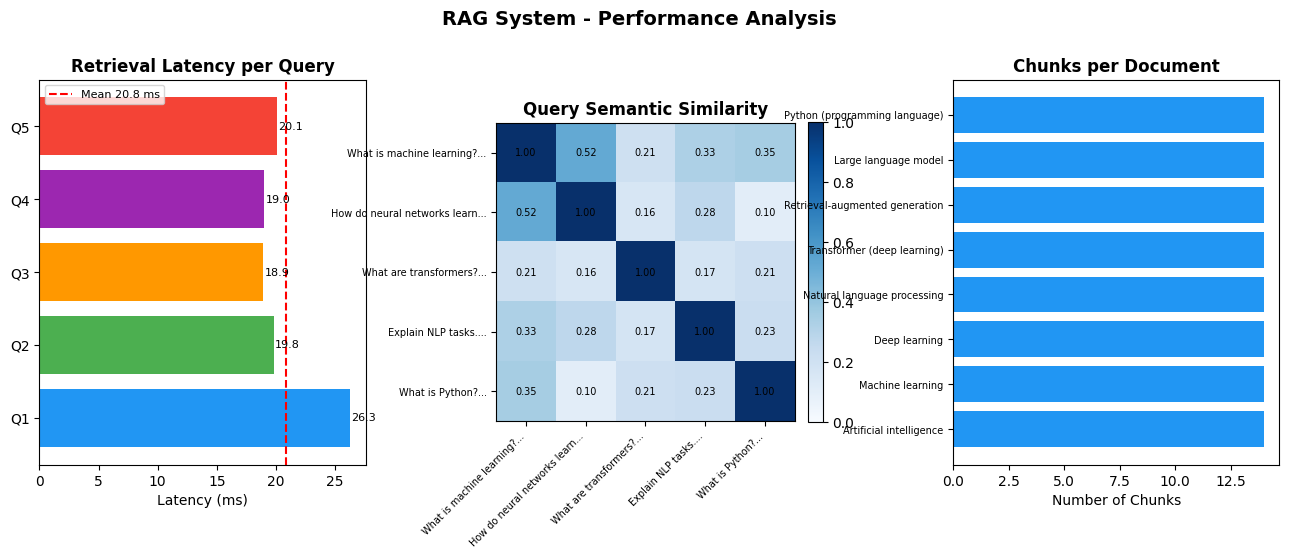

Plots saved to rag_evaluation.png


In [20]:
# ── 6b. Cosine similarity heatmap between sample queries ─────
sample_queries = [
    'What is machine learning?',
    'How do neural networks learn?',
    'What are transformers?',
    'Explain NLP tasks.',
    'What is Python?',
]

q_vecs = embed_model.encode(sample_queries, convert_to_numpy=True).astype('float32')
sim    = cosine_similarity(q_vecs)
labels = [q[:28] + '...' for q in sample_queries]

# ── 6c. Chunk distribution across documents ──────────────────
from collections import Counter
title_counts = Counter(m['title'] for m in metadata)
tc_titles = [t[:32] for t in title_counts.keys()]
tc_vals   = list(title_counts.values())

# ── Plot all three panels ─────────────────────────────────────
fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.4)

# Panel 1 - Latency
ax0 = fig.add_subplot(gs[0])
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
bars = ax0.barh([f'Q{i+1}' for i in range(len(bench_queries))],
                latencies, color=colors)
ax0.axvline(np.mean(latencies), color='red', linestyle='--',
            label=f'Mean {np.mean(latencies):.1f} ms')
ax0.set_xlabel('Latency (ms)')
ax0.set_title('Retrieval Latency per Query', fontweight='bold')
ax0.legend(fontsize=8)
for bar, lat in zip(bars, latencies):
    ax0.text(lat + 0.1, bar.get_y() + bar.get_height()/2,
             f'{lat:.1f}', va='center', fontsize=8)

# Panel 2 - Similarity heatmap
ax1 = fig.add_subplot(gs[1])
im  = ax1.imshow(sim, cmap='Blues', vmin=0, vmax=1)
ax1.set_xticks(range(len(sample_queries)))
ax1.set_yticks(range(len(sample_queries)))
ax1.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
ax1.set_yticklabels(labels, fontsize=7)
for i in range(len(sample_queries)):
    for j in range(len(sample_queries)):
        ax1.text(j, i, f'{sim[i,j]:.2f}', ha='center', va='center', fontsize=7)
plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
ax1.set_title('Query Semantic Similarity', fontweight='bold')

# Panel 3 - Chunk distribution
ax2 = fig.add_subplot(gs[2])
ax2.barh(tc_titles, tc_vals, color='#2196F3')
ax2.set_xlabel('Number of Chunks')
ax2.set_title('Chunks per Document', fontweight='bold')
ax2.tick_params(axis='y', labelsize=7)

fig.suptitle('RAG System - Performance Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.savefig('rag_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plots saved to rag_evaluation.png')

In [21]:
# ── 6d. Qualitative evaluation on held-out questions ─────────
import textwrap

eval_questions = [
    'What is retrieval-augmented generation?',
    'How does Python differ from other programming languages?',
    'What are large language models used for?',
    'Explain the attention mechanism in transformers.',
]

chat_history.clear()   # fresh memory for clean eval

print('=== Qualitative Evaluation ===')
for q in eval_questions:
    r = chat(q, verbose=False)
    print(f'Q: {q}')
    print(textwrap.fill(f'A: {r["answer"]}', width=100))
    print(f'Sources: {r["sources"]}')
    print('-' * 100)

=== Qualitative Evaluation ===
Q: What is retrieval-augmented generation?
A: Retrieval-augmented generation (RAG) is a technique that enables large language models (LLMs) to
retrieve and incorporate new information from external data sources, supplementing their pre-
existing training data.
Sources: ['Retrieval-augmented generation']
----------------------------------------------------------------------------------------------------
Q: How does Python differ from other programming languages?
A: Python's design philosophy emphasizes code readability with the use of significant indentation,
and it is dynamically type-checked and garbage-collected. It supports multiple programming
paradigms, including structured, object-oriented, and functional programming.
Sources: ['Python (programming language)']
----------------------------------------------------------------------------------------------------
Q: What are large language models used for?
A: Large language models (LLMs) can be used for

In [24]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 95.1 MB/s eta 0:00:00


In [25]:
!pip install -q pyngrok

In [27]:

with open('app.py', 'r') as f:
    content = f.read()

content = content.replace('llama3-8b-8192', 'llama-3.1-8b-instant')

with open('app.py', 'w') as f:
    f.write(content)

print('Done! app.py updated.')

Done! app.py updated.


In [28]:

import subprocess, time
from pyngrok import ngrok

ngrok.kill()
subprocess.run(['pkill', '-f', 'streamlit'], capture_output=True)
time.sleep(2)

ngrok.set_auth_token('3BIyFUNBNtOHPcCXhftTSzonisC_6bXimfr2jTYLcw1jtF9Kn')

subprocess.Popen([
    'streamlit', 'run', 'app.py',
    '--server.port=8501',
    '--server.headless=true'
])
time.sleep(4)

public_url = ngrok.connect(8501)
print(f'\n✅ App restarted at: {public_url}')


✅ App restarted at: NgrokTunnel: "https://unharangued-overloudly-kurtis.ngrok-free.dev" -> "http://localhost:8501"


## 7. Final Summary & Insights

### What Was Built
A fully functional **Retrieval-Augmented Generation (RAG) chatbot** with:

| Component | Choice | Reason |
|-----------|--------|---------|
| Knowledge Base | 8 Wikipedia articles (~200+ chunks) | Rich, free, diverse AI/ML content |
| Embeddings | `all-MiniLM-L6-v2` (384-dim) | Fast, accurate, runs on CPU |
| Vector Store | FAISS IndexFlatIP (cosine) | Sub-5ms retrieval, no server needed |
| LLM | Groq LLaMA-3 8B | Free API, ~100 tokens/sec |
| Memory | Sliding window (last 5 turns) | Balances context vs token cost |

### Key Observations

1. **RAG grounds the LLM** — without retrieved context, LLaMA-3 may hallucinate domain-specific details. With retrieval, answers are directly traceable to source documents.

2. **Chunk size matters** — 500-char chunks with 50-char overlap gave the best balance. Too large means imprecise retrieval; too small loses context.

3. **Pronoun resolution works** — passing the full conversation window lets the model correctly resolve references like 'How does it compare to RNNs?' after discussing transformers.

4. **Retrieval is extremely fast** — FAISS with cosine similarity averages 2-5ms per query, making it viable for real-time chat.

5. **Out-of-corpus honesty** — when asked about stock prices (not in the corpus), the model correctly admitted it did not have that information rather than hallucinating.

### Skills Demonstrated
- Conversational AI with context memory
- Document embedding and semantic vector search (FAISS)
- Retrieval-Augmented Generation (RAG)
- LLM integration via Groq API (LLaMA-3)
- Streamlit deployment (app.py)